# multi linear model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('2_oil_cost_analysis_dataset.csv')
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [2]:
df2=df.duplicated()
df2.value_counts()

False    5000
Name: count, dtype: int64

In [3]:
df.isnull().sum()

FlowRate_LPM    0
Pressure_Bar    0
TankLevel_L     0
OilCost_$       0
dtype: int64

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.corr()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
FlowRate_LPM,1.000000,-0.007015,-0.009517,0.824780
Pressure_Bar,-0.007015,1.000000,-0.022837,0.212833
TankLevel_L,-0.009517,-0.022837,1.000000,0.508463
OilCost_$,0.824780,0.212833,0.508463,1.000000


<Axes: >

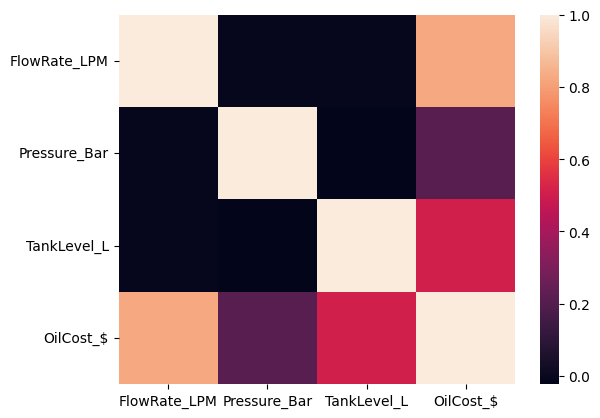

In [5]:
sns.heatmap(df.corr())

In [6]:
df

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52
...,...,...,...,...
4995,458.96,71.46,3603.53,654.53
4996,147.75,73.85,1711.19,314.54
4997,231.14,76.80,1204.96,360.36
4998,426.30,43.85,3731.85,593.40


In [7]:
df.describe()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,298.732838,49.489212,3005.500244,463.495078
std,115.853453,17.137032,1163.079301,111.483085
min,100.000000,20.000000,1000.630000,176.560000
25%,197.547500,34.827500,1988.670000,380.497500
50%,300.000000,49.155000,2984.790000,464.480000
75%,399.240000,64.000000,4042.475000,544.907500
max,499.890000,79.970000,4999.220000,753.320000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FlowRate_LPM  5000 non-null   float64
 1   Pressure_Bar  5000 non-null   float64
 2   TankLevel_L   5000 non-null   float64
 3   OilCost_$     5000 non-null   float64
dtypes: float64(4)
memory usage: 156.4 KB


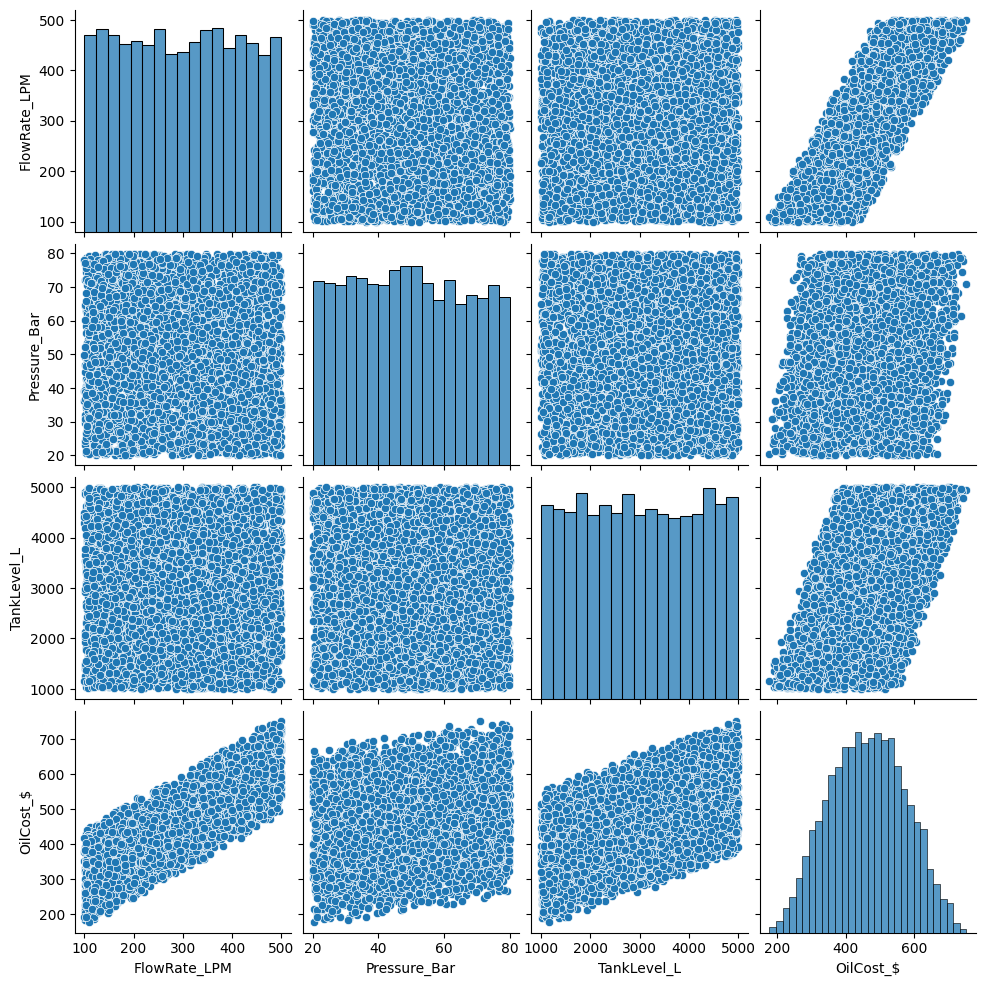

In [9]:
sns.pairplot(df)

In [10]:
df.corr(method='pearson')

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
FlowRate_LPM,1.000000,-0.007015,-0.009517,0.824780
Pressure_Bar,-0.007015,1.000000,-0.022837,0.212833
TankLevel_L,-0.009517,-0.022837,1.000000,0.508463
OilCost_$,0.824780,0.212833,0.508463,1.000000


Text(0.5, 0, 'FlowRate_LPM')

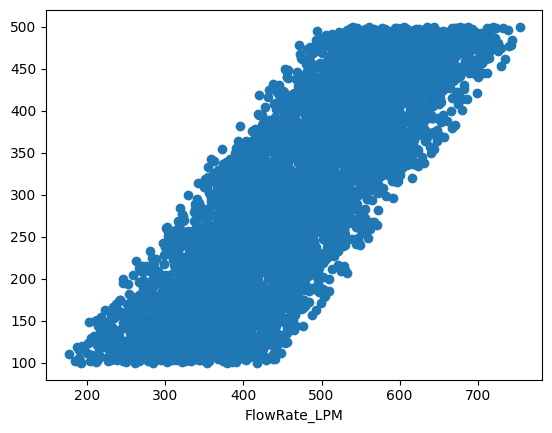

In [ ]:
plt .scatter(df['OilCost_$'],df['FlowRate_LPM'])
plt.xlabel('oil cost')
plt.xlabel('FlowRate_LPM')

In [12]:
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [13]:
#independent and dependent features 

x=df.iloc[:,:-1]
y=df.iloc[:,3]



In [14]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


<Axes: xlabel='FlowRate_LPM', ylabel='OilCost_$'>

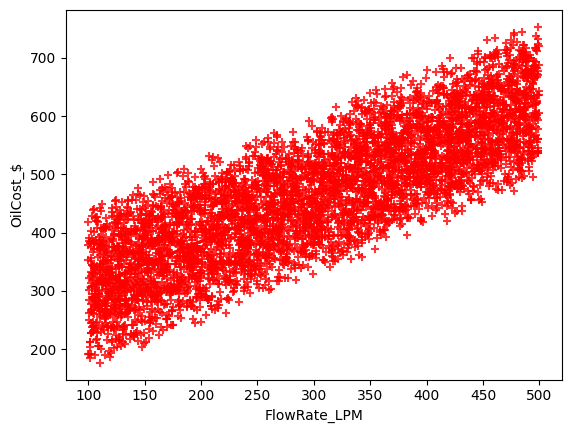

In [121]:
sns.regplot(x=df['FlowRate_LPM'],y=df['OilCost_$'],color='RED',marker='+')

In [16]:
from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()


In [17]:
scalar.fit_transform(x_train)
scalar.transform(x_test)


array([[-0.07034235, -1.45084182,  1.3342313 ],
       [-1.47667007, -0.26647163, -1.00039925],
       [-1.54372436,  1.11909527, -0.14896384],
       ...,
       [-1.2935437 ,  1.3267256 , -0.78088761],
       [ 0.47713821, -1.64911417, -0.37780059],
       [-0.33433084, -0.22494557, -1.39518   ]], shape=(1250, 3))

In [18]:
from sklearn.linear_model import LinearRegression

regress=LinearRegression()

In [19]:
regress.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
from sklearn.model_selection import cross_val_score

val_scor=cross_val_score(regress,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [21]:
val_scor

array([-3.18859687e-05, -3.00014155e-05, -3.23149877e-05])

In [22]:
np.mean(val_scor)

np.float64(-3.140079063286164e-05)

In [104]:
x_train,x_test

(      FlowRate_LPM  Pressure_Bar  TankLevel_L
 4884        143.95         23.29      2679.36
 3163        301.05         48.86      1396.23
 490         282.26         29.38      1985.91
 862         309.76         20.45      1432.58
 1740        431.02         30.27      2289.33
 ...            ...           ...          ...
 4426        194.77         37.12      3827.64
 466         214.28         66.66      2695.82
 3092        259.61         55.15      1679.36
 3772        237.58         53.37      4072.99
 860         410.21         47.32      4798.15
 
 [3750 rows x 3 columns],
       FlowRate_LPM  Pressure_Bar  TankLevel_L
 1501        291.67         24.80      4537.99
 2586        128.71         45.05      1834.11
 2653        120.94         68.74      2820.21
 1055        240.28         49.58      2385.45
 705         495.98         35.94      3356.85
 ...            ...           ...          ...
 4141        153.83         31.90      3820.76
 3168        405.78         46.1

,x,y,group
1501,497.435744,497.44,497.435744
2586,262.248269,262.24,262.248269
2653,340.872254,340.87,340.872254
1055,385.866343,385.87,385.866343
705,618.536607,618.54,618.536607
...,...,...,...
4141,361.952081,361.96,361.952081
3168,556.205511,556.21,556.205511
2478,332.795658,332.80,332.795658
4214,443.962049,443.96,443.962049


In [69]:
y_pred=regress.predict(x_test)

In [24]:
y_pred

array([497.43574446, 262.24826926, 340.87225433, ..., 332.79565795,
       443.96204927, 346.34825129], shape=(1250,))

In [129]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred)
perc=(score*100)
perc

99.99999975568845

In [26]:
from sklearn.metrics import r2_score

# Calculate R-squared
score = r2_score(y_test, y_pred)
print("r2->",score)

# Display Adjusted R-squared
print(1 - (1 - score) * ((len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)))

r2-> 0.9999999975568845
0.9999999975510022


In [56]:
y_test

1501    497.44
2586    262.24
2653    340.87
1055    385.87
705     618.54
         ...  
4141    361.96
3168    556.21
2478    332.80
4214    443.96
4180    346.35
Name: OilCost_$, Length: 1250, dtype: float64

In [57]:
y_pred

array([497.43574446, 262.24826926, 340.87225433, ..., 332.79565795,
       443.96204927, 346.34825129], shape=(1250,))

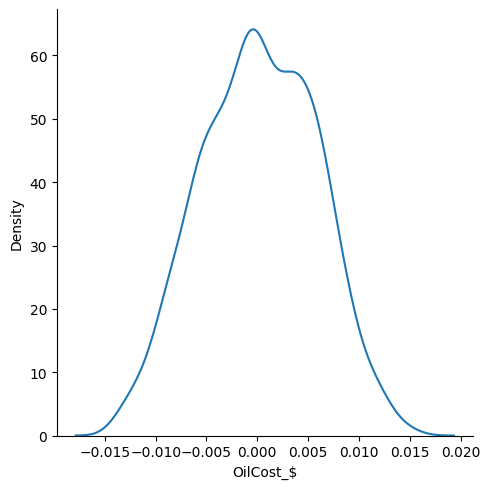

In [65]:
# assumptions
residuals=y_test-y_pred
# residuals.head(10)
sns.displot(residuals,kind='kde')

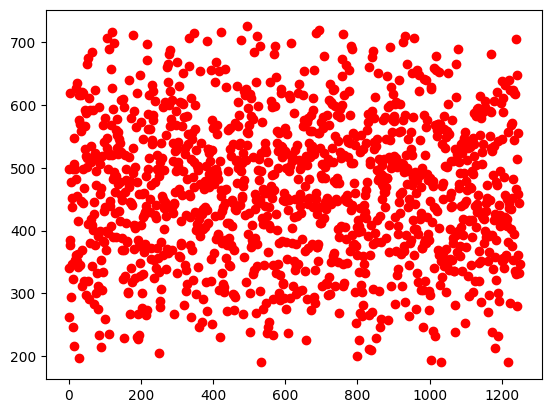

In [ ]:
x=range(len(y_test))

plt.scatter(x,y_test,color='red')


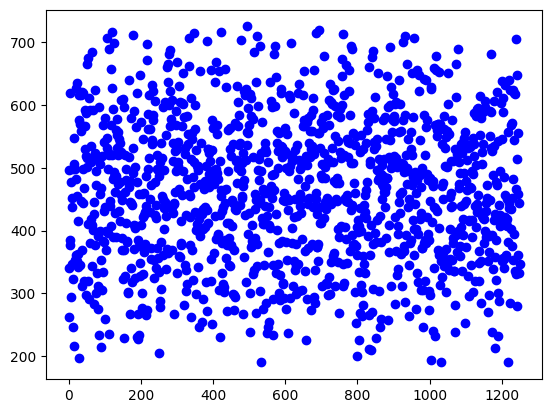

In [102]:
plt.scatter(x,y_pred,color='blue')

In [29]:
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [142]:
# predicting 

print("the cost of oil will be",regress.predict([[564.82,54.41,3211]])[0],"$")

the cost of oil will be 694.0210100921638 $


In [31]:
import pickle

In [32]:
with open('oil_cost_predict_model.pkl','wb') as file:
    pickle.dump(regress,file)

In [33]:
with open('oil_cost_predict_model.pkl','rb') as file:
    model=pickle.load(file)

    

In [38]:
import warnings

warnings.filterwarnings('ignore')

In [134]:
print((model.predict([[348.82,56.41,4475]])[0]).round(2),end=' $')

587.42 $

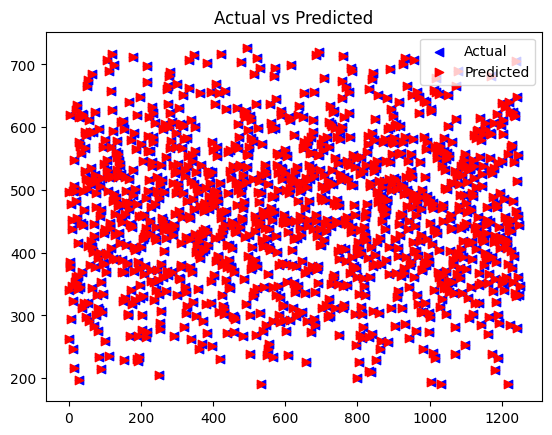

In [140]:
plt.scatter(range(len(y_test)), y_test, label='Actual', color='blue',marker='<')
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', color='red', marker='>')


plt.title('Actual vs Predicted')
plt.legend()
plt.show()

Text(0.5, 1.0, ' Actual vs Predicted')

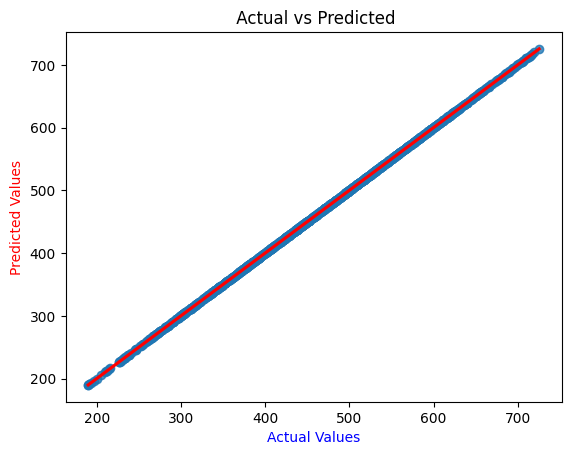

In [151]:
sns.regplot(x=y_test, y=y_pred, label=['Actual','predicted'], line_kws={"color":"red"})
plt.xlabel('Actual Values',color='blue')
plt.ylabel('Predicted Values',color='red')
plt.title(' Actual vs Predicted')